In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)

file_path = "../data/Groceries_dataset.csv"
df = pd.read_csv(file_path,encoding="Unicode_escape")

In [2]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

print(f"Sətir sayı: {df.shape[0]:,}")
print(f"Unikal müştəri (Member_number): {df['Member_number'].nunique():,}")
print(f"Unikal məhsul (itemDescription): {df['itemDescription'].nunique()}")
print(f"Tarix aralığı: {df['Date'].min().date()}  ->  {df['Date'].max().date()}")
 
df.head()

Sətir sayı: 38,765
Unikal müştəri (Member_number): 3,898
Unikal məhsul (itemDescription): 167
Tarix aralığı: 2014-01-01  ->  2015-12-30


,Member_number,Date,itemDescription
0,1808,2015-07-21,tropical fruit
1,2552,2015-01-05,whole milk
2,2300,2015-09-19,pip fruit
3,1187,2015-12-12,other vegetables
4,3037,2015-02-01,whole milk


In [3]:
baskets = df.groupby(['Member_number', 'Date']).agg(
    basket_size=('itemDescription', 'count')
).reset_index()

print(f"Unikal basket sayı: {len(baskets):,}")
print(f"Orta basket ölçüsü: {baskets['basket_size'].mean():.2f}")
print(f"Median basket ölçüsü: {baskets['basket_size'].median()}")
print(f"Maksimum basket ölçüsü: {baskets['basket_size'].max()}")
print(f"Minimum basket ölçüsü: {baskets['basket_size'].min()}")

baskets['basket_size'].describe()

Unikal basket sayı: 14,963
Orta basket ölçüsü: 2.59
Median basket ölçüsü: 2.0
Maksimum basket ölçüsü: 11
Minimum basket ölçüsü: 2


count    14963.000000
mean         2.590724
std          1.117469
min          2.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         11.000000
Name: basket_size, dtype: float64

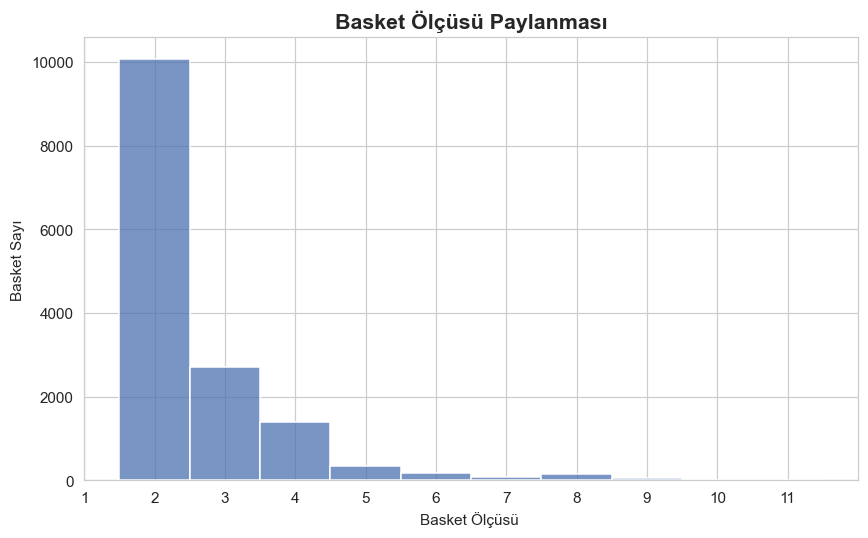

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(baskets['basket_size'], bins=range(1, 13), discrete=True,
             color='#4C72B0', edgecolor='white', ax=ax)

ax.set_title('Basket Ölçüsü Paylanması', fontsize=14, fontweight='bold')
ax.set_xlabel('Basket Ölçüsü ')
ax.set_ylabel('Basket Sayı')
ax.set_xticks(range(1, 12))
plt.tight_layout()
plt.savefig('basket_size_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
visit_freq = df.groupby('Member_number')['Date'].nunique().reset_index(name='visits')
def frequency_group(v):
    if v == 1:
        return '1 ziyarət'
    elif 2 <= v <= 5:
        return '2-5 ziyarət'
    elif 6 <= v <= 10:
        return '6-10 ziyarət'
    else:
        return '10+ ziyarət'

visit_freq['FrequencyGroup'] = visit_freq['visits'].apply(frequency_group)

group_order = ['1 ziyarət', '2-5 ziyarət', '6-10 ziyarət', '10+ ziyarət']
freq_summary = visit_freq['FrequencyGroup'].value_counts().reindex(group_order)
freq_pct = (visit_freq['FrequencyGroup'].value_counts(normalize=True).reindex(group_order) * 100).round(2)

freq_table = pd.DataFrame({'Customer_Count': freq_summary, 'Pct_of_Customers': freq_pct})
freq_table

,Customer_Count,Pct_of_Customers
FrequencyGroup,,
1 ziyarət,349,8.95
2-5 ziyarət,2819,72.32
6-10 ziyarət,725,18.60
10+ ziyarət,5,0.13


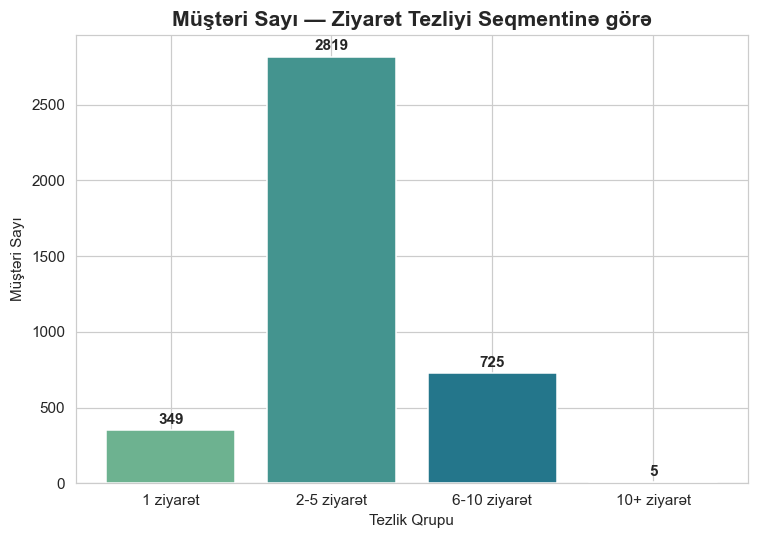

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = sns.color_palette('crest', len(group_order))
bars = ax.bar(group_order, freq_summary.values, color=colors, edgecolor='white')

for bar, val in zip(bars, freq_summary.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 20, str(val),
            ha='center', va='bottom', fontweight='bold')

ax.set_title('Müştəri Sayı — Ziyarət Tezliyi Seqmentinə görə', fontsize=14, fontweight='bold')
ax.set_xlabel('Tezlik Qrupu')
ax.set_ylabel('Müştəri Sayı')
plt.tight_layout()
plt.savefig('customer_frequency_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
top20 = df['itemDescription'].value_counts().head(20)
top20


itemDescription
whole milk            2502
other vegetables      1898
rolls/buns            1716
soda                  1514
yogurt                1334
root vegetables       1071
tropical fruit        1032
bottled water          933
sausage                924
citrus fruit           812
pastry                 785
pip fruit              744
shopping bags          731
canned beer            717
bottled beer           687
whipped/sour cream     662
newspapers             596
frankfurter            580
brown bread            571
pork                   566
Name: count, dtype: int64

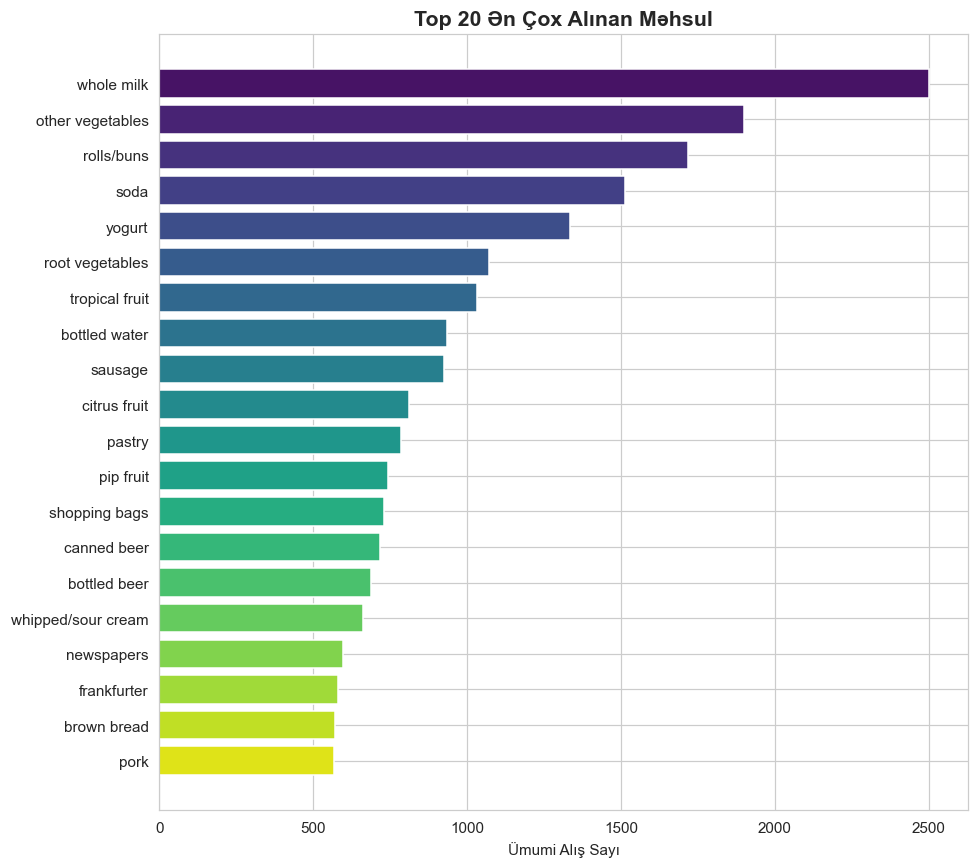

In [10]:
fig, ax = plt.subplots(figsize=(9, 8))
colors = sns.color_palette('viridis', len(top20))
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_title('Top 20 Ən Çox Alınan Məhsul', fontsize=14, fontweight='bold')
ax.set_xlabel('Ümumi Alış Sayı')
plt.tight_layout()
plt.savefig('top20_products.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
df['DayOfWeek'] = df['Date'].dt.day_name()
baskets['DayOfWeek'] = baskets['Date'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

transactions_by_day = df['DayOfWeek'].value_counts().reindex(day_order)
baskets_by_day = baskets['DayOfWeek'].value_counts().reindex(day_order)
avg_basket_by_day = baskets.groupby('DayOfWeek')['basket_size'].mean().reindex(day_order)

day_summary = pd.DataFrame({
    'Transaction_Rows': transactions_by_day,
    'Unique_Baskets': baskets_by_day,
    'Avg_Basket_Size': avg_basket_by_day.round(2)
})
day_summary

,Transaction_Rows,Unique_Baskets,Avg_Basket_Size
DayOfWeek,,,
Monday,5382,2067,2.60
Tuesday,5558,2142,2.59
Wednesday,5562,2131,2.61
Thursday,5620,2188,2.57
Friday,5562,2136,2.60
Saturday,5551,2161,2.57
Sunday,5530,2138,2.59


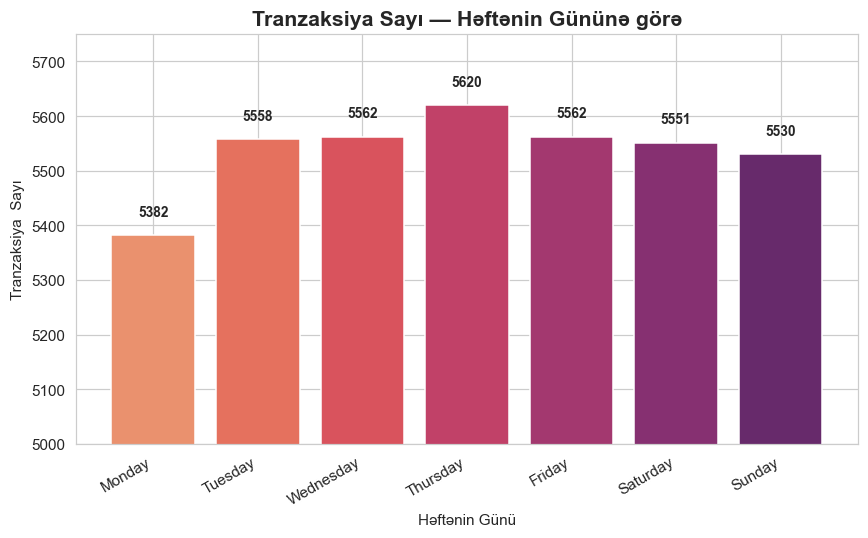

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('flare', len(day_order))
bars = ax.bar(day_order, transactions_by_day.values, color=colors, edgecolor='white')
for bar, val in zip(bars, transactions_by_day.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 30, str(val),
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Tranzaksiya Sayı — Həftənin Gününə görə', fontsize=14, fontweight='bold')
ax.set_xlabel('Həftənin Günü')
ax.set_ylabel('Tranzaksiya  Sayı')
plt.xticks(rotation=30, ha='right')
ax.set_ylim(5000, 5750)
plt.tight_layout()
plt.savefig('transactions_by_weekday.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
basket_items = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(
    lambda x: sorted(set(x))
).reset_index()

pair_counter = Counter()
for items in basket_items['itemDescription']:
    if len(items) >= 2:
        for pair in combinations(items, 2):
            pair_counter[pair] += 1

top_pairs = pd.DataFrame(pair_counter.most_common(10), columns=['Product_Pair', 'Co_occurrence_Count'])
top_pairs

,Product_Pair,Co_occurrence_Count
0,"(other vegetables, whole milk)",222
1,"(rolls/buns, whole milk)",209
2,"(soda, whole milk)",174
3,"(whole milk, yogurt)",167
4,"(other vegetables, rolls/buns)",158
5,"(other vegetables, soda)",145
6,"(sausage, whole milk)",134
7,"(tropical fruit, whole milk)",123
8,"(other vegetables, yogurt)",121
9,"(rolls/buns, soda)",121


In [14]:
customer_basket_counts = baskets.groupby('Member_number').size().sort_values(ascending=False)
top10_customers = customer_basket_counts.head(10)
total_baskets = len(baskets)
top10_pct = top10_customers.sum() / total_baskets * 100
print(f"Top 10 müştəri ümumi basket-lərin {top10_pct:.2f}%-ni təşkil edir")
print()
print(top10_customers)

Top 10 müştəri ümumi basket-lərin 0.70%-ni təşkil edir

Member_number
2271    11
4338    11
3737    11
1379    11
2193    11
4376    10
4864    10
1410    10
3484    10
4217    10
dtype: int64


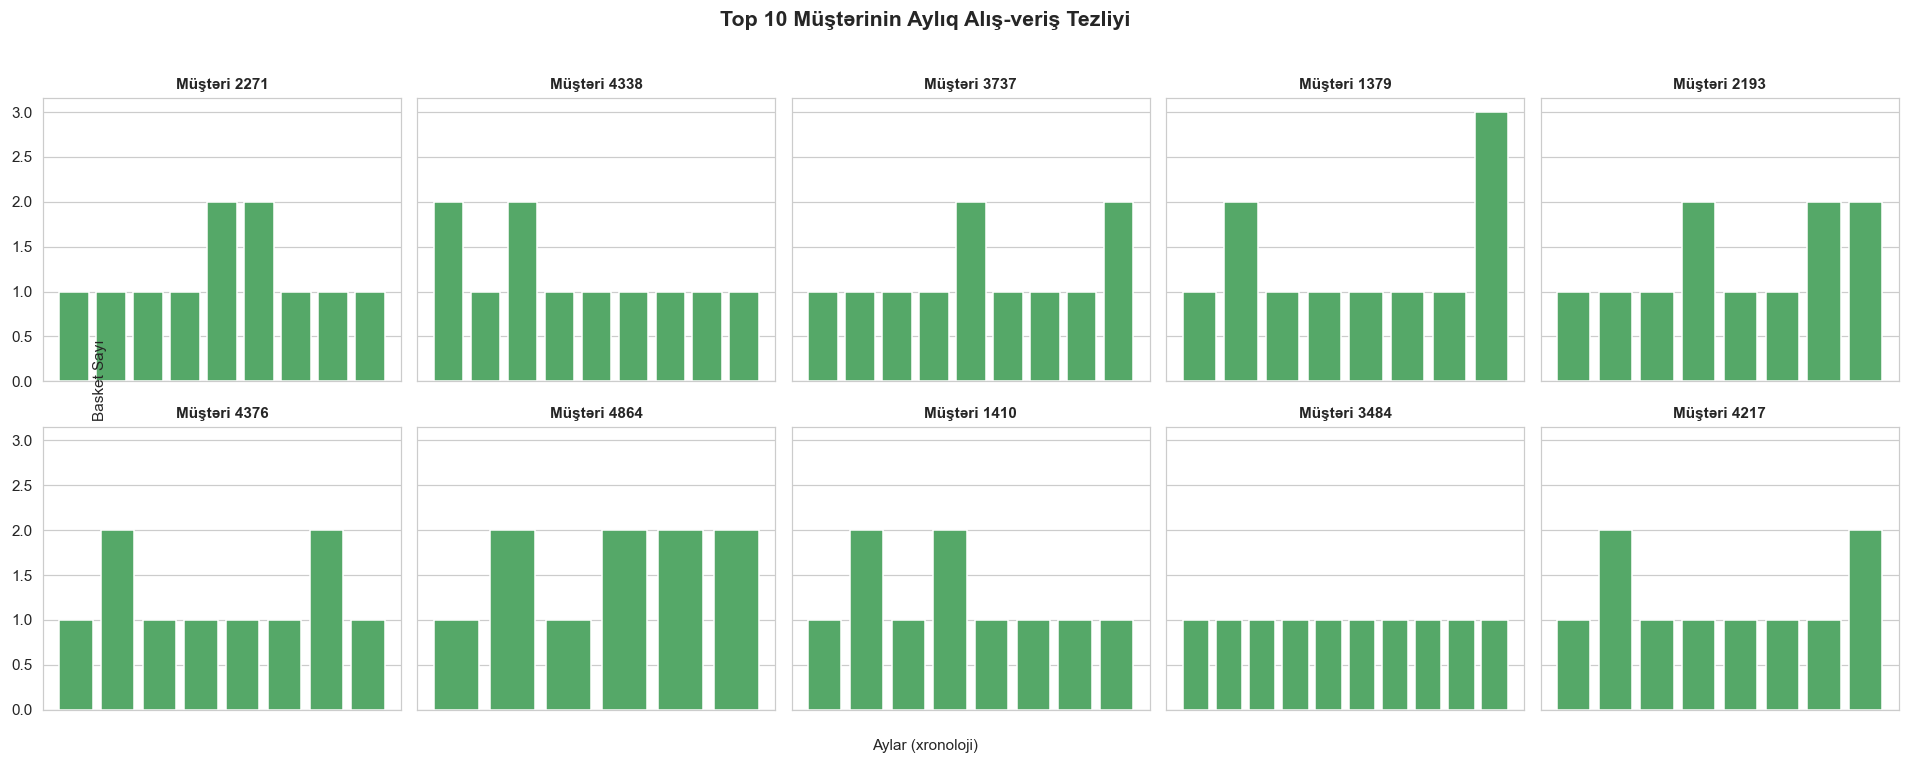

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
axes = axes.flatten()
for i, member in enumerate(top10_customers.index):
    cust_baskets = baskets[baskets['Member_number'] == member].copy()
    cust_baskets['YearMonth'] = cust_baskets['Date'].dt.to_period('M').astype(str)
    monthly = cust_baskets.groupby('YearMonth').size()

    axes[i].bar(range(len(monthly)), monthly.values, color='#55A868', edgecolor='white')
    axes[i].set_title(f'Müştəri {member}', fontsize=10, fontweight='bold')
    axes[i].set_xticks([])

fig.suptitle('Top 10 Müştərinin Aylıq Alış-veriş Tezliyi', fontsize=14, fontweight='bold')
fig.text(0.5, 0.02, 'Aylar (xronoloji)', ha='center')
fig.text(0.08, 0.5, 'Basket Sayı', va='center', rotation='vertical')
plt.tight_layout(rect=[0.03, 0.04, 1, 0.96])
plt.savefig('top10_customers_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
